In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score,
)
from sklearn.impute import SimpleImputer

In [34]:
DATA_DIR = "../../data/raw/final_dataset.csv"

# adjust to not use much memory, i just crashed my desktop
CHUNK_SIZE = 200_000
MAX_LABEL = 100_000

In [35]:
counts = {}
parts = []

for chunk in pd.read_csv(DATA_DIR, chunksize=CHUNK_SIZE):
    for label, group in chunk.groupby("Label"):
        n = counts.get(label, 0)
        if n >= MAX_LABEL:
            continue

        # iloc is "integer location", just row by position exactly like array slicing
        take = group.iloc[: MAX_LABEL - n]
        parts.append(take)
        counts[label] = n + len(take)

    # stop once we have two labels and MAX_LABEL rows for each
    if len(counts) == 2 and all(c >= MAX_LABEL for c in counts.values()):
        break

# ignore_index resets row numbers, so we go from 0..MAX_LABEL*2
df = pd.concat(parts, ignore_index=True)

# dataframes let you index by column
print(df["Label"].value_counts())

Label
ddos      100000
Benign    100000
Name: count, dtype: int64


In [40]:
"""
Numeric features:
    Because kNN uses stuff like Euclidean difference for distances, it relies of course on numeric points.
    Therefore we drop columns that are either non-numeric or irrelevant.

    NOTE: I think src IP is irrelevant as this is a _distributed_ dos but maybe it isn't?
          Timestamp may also be relevant, but probably not because of the same reason. Multiple people visiting
          in quick successsion doesn't mean a ddos itself.
"""

columns_to_drop = ["Label", "Unnamed: 0", "Flow ID", "Src IP", "Dst IP", "Timestamp"]
X = df.drop(columns=columns_to_drop).values
y = df["Label"].values

# sklearn needs numeric labels so 1 for 'ddos' 0 for 'Benign'
y_numeric = np.where(y == "ddos", 1, 0)

print(f"\nFeature matrix shape: {X.shape}")
print(f"Label vector shape: {y_numeric.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"Feature columns: {list(df.drop(columns=columns_to_drop).columns)}")


Feature matrix shape: (200000, 79)
Label vector shape: (200000,)
Number of features: 79
Feature columns: ['Src Port', 'Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg'

In [42]:
"""
Cleaning:
   There were some issues with inf being present, so we replace those with NaN.
   Then we replace NaN with column median. Median is better than mean wrt outliers.
"""

X = np.where(np.isinf(X), np.nan, X)

imputer = SimpleImputer(strategy="median")
X = imputer.fit_transform(X)

In [43]:
"""
Splitting data:
  - 60% training
  - 20% validation (we'll tune hyperparameters here)
  - 20% test
"""

X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y_numeric,
    test_size=0.2,
    random_state=1,  # Seeded so we can reproduce
    stratify=y_numeric,  # Split across 'ddos' and 'Benign'
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp
)

In [ ]:
"""
Feature scaling:
    Because we're working with distances we wanna do some scaling. 
    `StandardScaler` gives us mean 0, stddev 1, which sounds good to me. 
    We fit the scaler only on training data, and then transform all data using it.
    If our training data is representative then this works.
"""

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Training data mean: {X_train_scaled.mean():.6f} should be 0, stddev: {X_train_scaled.std():.6f} should be 1.")

In [ ]:
"""
Hyperparameter tuning:
    We're changing `k`, the number of neighbours.
    Small `k` is sensitive to noise and can overfit.
    Big `k` can underfit but generally better I think?
"""

k_values = range(1, 51, 2)  # odd numbers apparently better
val_accuracies = []
train_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    # Evaluate on training set, which checks for overfitting.
    train_acc = accuracy_score(y_train, knn.predict(X_train_scaled))
    train_accuracies.append(train_acc)

    # Evaluate on validation set, to find best hyperparameter.
    val_acc = accuracy_score(y_val, knn.predict(X_val_scaled))
    val_accuracies.append(val_acc)

# Best k based on accuracy.
best_k_idx = np.argmax(val_accuracies)
best_k = list(k_values)[best_k_idx]
best_val_acc = val_accuracies[best_k_idx]

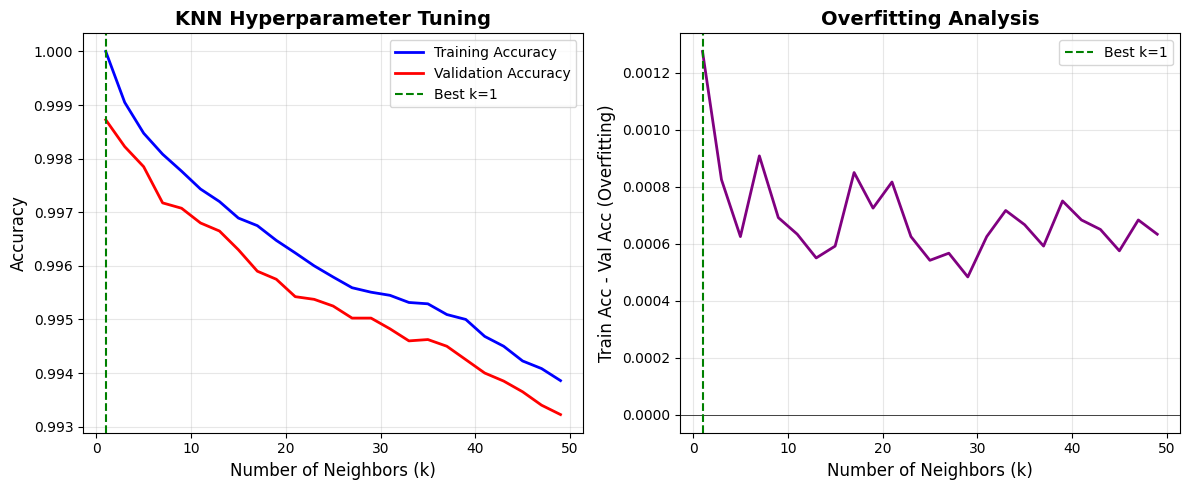

In [48]:
"""
Visualising:
    Accuracy versus k to visually see which is best and if there are trends that'll reveal
"""

plt.figure(figsize=(12, 5))

# Accuracy vs k
plt.subplot(1, 2, 1)
plt.plot(k_values, train_accuracies, "b-", label="Training Accuracy", linewidth=2)
plt.plot(k_values, val_accuracies, "r-", label="Validation Accuracy", linewidth=2)
plt.axvline(x=best_k, color="g", linestyle="--", label=f"Best k={best_k}")
plt.xlabel("Number of Neighbors (k)", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("KNN Hyperparameter Tuning", fontsize=14, fontweight="bold")
plt.legend()
plt.grid(True, alpha=0.3)

# Diff between training/validation (overfitting)
plt.subplot(1, 2, 2)
overfit_gap = np.array(train_accuracies) - np.array(val_accuracies)
plt.plot(k_values, overfit_gap, "purple", linewidth=2)
plt.axhline(y=0, color="black", linestyle="-", linewidth=0.5)
plt.axvline(x=best_k, color="g", linestyle="--", label=f"Best k={best_k}")
plt.xlabel("Number of Neighbors (k)", fontsize=12)
plt.ylabel("Train Acc - Val Acc (Overfitting)", fontsize=12)
plt.title("Overfitting Analysis", fontsize=14, fontweight="bold")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../../plots/hyperparameter_tuning.png", dpi=300, bbox_inches="tight")

In [47]:
"""
Training
"""
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)


Best k: 1 (Validation accuracy: 0.9987)


In [ ]:
"""
Evaluate on test data:
    We do this only once!!! 
"""

y_test_pred = final_knn.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"\nTest Accuracy: {test_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, 
                          target_names=['Benign', 'DDoS'],
                          digits=4))


In [ ]:
"""
Confusion matrix:
    We can use this to then make a ROC and AUC to see TPR/FPR and performance
"""
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title(f'Confusion Matrix - KNN (k={best_k})', fontsize=14, fontweight='bold')
plt.colorbar(label='Count')

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=16)

tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Benign', 'DDoS'], fontsize=12)
plt.yticks(tick_marks, ['Benign', 'DDoS'], fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('../../plots/confusion_matrix.png', dpi=300, bbox_inches='tight')



In [ ]:
"""
ROC and AUC:
    ROC shows tradeoff between TPR and FPR. 
    AUC shows overall performance, with 1 perfect and 0.5 random.
    NOTE: something to talk about in report is how much we actually care about TPR and FPR.
"""

y_test_proba = final_knn.predict_proba(X_test_scaled)[:, 1]  # prob of ddos (label 1)
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', linewidth=2, 
         label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linewidth=2, linestyle='--', 
         label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title(f'ROC Curve - KNN (k={best_k})', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../../plots/roc_curve.png', dpi=300, bbox_inches='tight')

print(f"\nROC AUC Score: {roc_auc:.4f}")


In [49]:

"""
Cross validation:
    We do 5-fold CV. I assume this is splitting validation set into 5 pieces, but it might be a sliding window?
    We do it with combined train/validation because we're already done with hyperparameters and more data = good
"""
# Combine train and validation for CV (since we already selected hyperparameters)
X_trainval = np.vstack([X_train_scaled, X_val_scaled])
y_trainval = np.concatenate([y_train, y_val])

cv_scores = cross_val_score(final_knn, X_trainval, y_trainval, 
                            cv=5, scoring='accuracy')

print(f"\n5-Fold Cross-Validation Results:")
print(f"Scores per fold: {cv_scores}")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")

# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"Dataset Size: {len(X)} samples")
print(f"Features: {X.shape[1]}")
print(f"Classes: Benign (0), DDoS (1)")
print(f"\nBest k value: {best_k}")
print(f"Validation Accuracy: {best_val_acc:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"CV Mean Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")
print("=" * 70)

plt.show()

SyntaxError: unterminated triple-quoted string literal (detected at line 135) (2763664880.py, line 102)